## EDA (Exploratory Data Analysis)

In [1]:
## Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Load Dataset
df = pd.read_csv("../data/processed/Cleaned-Telco-Customer-Churn.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Business Overview Questions

### 1. What is the overall churn rate of customers in the dataset?

In [3]:
churn_rate = round((df['Churn'].value_counts()/len(df['Churn']))*100, 2)
churn_rate

Churn
No     73.42
Yes    26.58
Name: count, dtype: float64

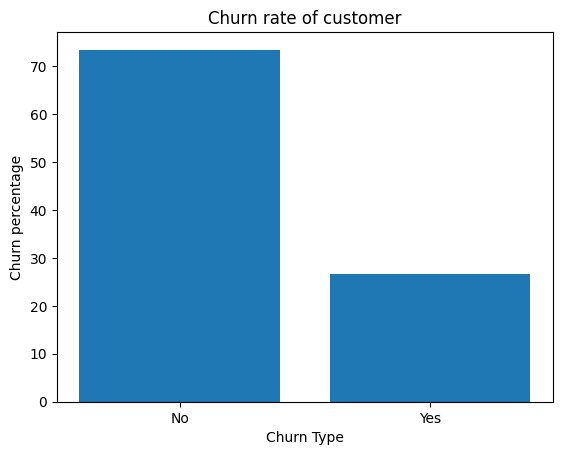

In [4]:
plt.bar(x=churn_rate.keys(), height=churn_rate.values)
plt.xlabel("Churn Type")
plt.ylabel("Churn percentage")
plt.title("Churn rate of customer");

#### Comments:
We can see that customer churn rate is approximately 26.58% in the dataset, indicating that about one in four customers have discontinued their service. This high churn rate suggests that the company may need to investigate the underlying reasons for customer attrition and implement strategies to improve customer retention.

### 2. How does churn vary by customer tenure (new vs long-term customers)?

We can categorize customers based on their tenure into three groups:
* New Customers (0-6 months) - High risky as they are still evaluating the service.
* Mid-term Customers (6-24 months) - Moderate risk as they have some experience with the service.
* Long-term Customers (24+ months) - Low risk as they are more likely to be satisfied with the service.

In [5]:
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 62, 13, 16, 58, 49, 69, 52, 71, 21, 12,
       30, 47, 17, 72,  5, 46, 11, 70, 63, 43, 25, 60, 18,  9,  3, 31, 50,
       64, 56,  7, 42, 35, 48, 29, 66, 65, 38, 68, 32, 55, 37, 36, 41, 27,
        6,  4, 33, 67, 23, 57, 61, 15, 14, 20, 53, 40, 59, 24, 44, 19, 54,
       51, 28, 26, 39])

In [8]:
df1 = df

In [ ]:
## Customer segmentation
df['tenure'] = df['tenure'].apply(lambda x: 'new' if x<=6 else('midterm' if 6<x<=24 else 'longterm'))

df['tenure']

0            new
1       longterm
2            new
3       longterm
4            new
          ...   
7016    longterm
7017     midterm
7018     midterm
7019         new
7020    longterm
Name: tenure, Length: 7021, dtype: object

In [28]:
## How churn vary by customer tenure
tenure_wise_churn_rate = df.groupby(['tenure'])['Churn'].value_counts(normalize=True).round(2).to_frame()
tenure_wise_churn_rate

proportion
tenure   Churn            
longterm No           0.86
         Yes          0.14
midterm  No           0.68
         Yes          0.32
new      Yes          0.53
         No           0.47

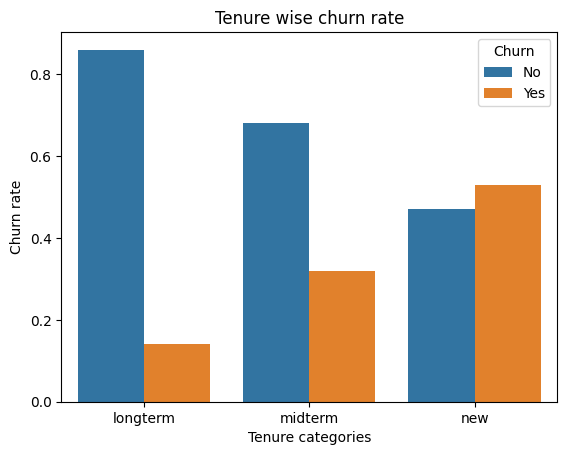

In [30]:
sns.barplot(data=tenure_wise_churn_rate, x='tenure', y='proportion', hue='Churn')
plt.title("Tenure wise churn rate")
plt.xlabel("Tenure categories")
plt.ylabel("Churn rate");

#### Comments:
The above analysis shows that:
* New customers (0-6 months) have the highest churn rate at approximately 53%, indicating that they are more likely to discontinue the service shortly after joining. 
* Mid-term customers (6-24 months) have a moderate churn rate of around 32%, 
* While long-term customers (24+ months) exhibit the lowest churn rate at about 14%. 

This trend suggests that customer retention improves with longer tenure, highlighting the importance of engaging and satisfying new customers to reduce early churn.

### 3. What percentage of total revenue is at risk due to churn?

In [56]:
## Percentage of tatal revenue based on churn
(df.groupby(['Churn'])['TotalCharges'].sum()/df['TotalCharges'].sum()).round(2)*100

Churn
No     82.0
Yes    18.0
Name: TotalCharges, dtype: float64

##### Comments:
The analysis indicates that approximately 20% of total revenue is at risk due to customer churn. This significant percentage highlights the financial impact of churn on the company's revenue stream.

### 4. How does churn trend differ across monthly vs yearly contracts?

In [61]:
## Churn trend on different contract type
contract_wist_churn_rate = df.groupby(['Contract'])['Churn'].value_counts(normalize=True).round(2).to_frame()

contract_wist_churn_rate

proportion
Contract       Churn            
Month-to-month No           0.57
               Yes          0.43
One year       No           0.89
               Yes          0.11
Two year       No           0.97
               Yes          0.03

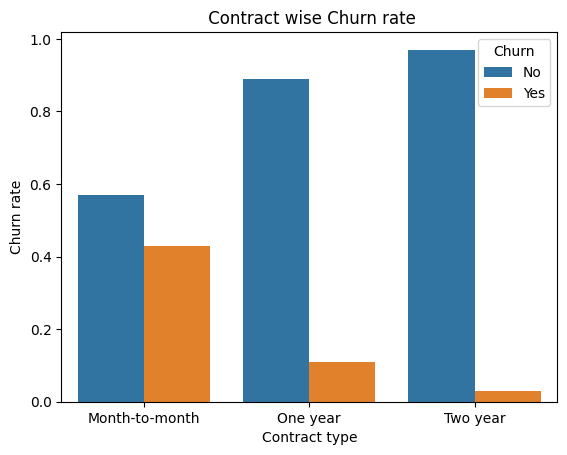

In [65]:
sns.barplot(data=contract_wist_churn_rate, x='Contract', y='proportion', hue='Churn')
plt.title(" Contract wise Churn rate")
plt.xlabel('Contract type')
plt.ylabel('Churn rate');

#### Comments:
The analysis indicates that:
* Month-to-month contract customers have a significantly higher churn rate (approximately 43%) compared to those on one-year (around 11%) and two-year contracts (about 3%). 

This suggests that customers with longer-term commitments are less likely to churn.

### 5. Which customer segments contribute most to churn volume?

In [66]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,new,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,longterm,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [81]:
## Customer segment 
customer_segment_with_churn = pd.pivot_table(data=df, index=['Churn', 'tenure'], columns=['Contract'], aggfunc='size').loc['Yes', :].fillna(0)

customer_segment_with_churn

Contract,Month-to-month,One year,Two year
tenure,,,
longterm,352.0,137.0,48.0
midterm,521.0,25.0,0.0
new,779.0,4.0,0.0


In [ ]:
customer_segment_with_churn_pct = ((customer_segment_with_churn/customer_segment_with_churn.sum().sum())*100).round(2)

customer_segment_with_churn_pct

Contract,Month-to-month,One year,Two year
tenure,,,
longterm,18.86,7.34,2.57
midterm,27.92,1.34,0.00
new,41.75,0.21,0.00


In [94]:
filtered_customer_segment_with_churn_pct = customer_segment_with_churn_pct.stack()[customer_segment_with_churn_pct.stack()>0]

filtered_customer_segment_with_churn_pct

tenure    Contract      
longterm  Month-to-month    18.86
          One year           7.34
          Two year           2.57
midterm   Month-to-month    27.92
          One year           1.34
new       Month-to-month    41.75
          One year           0.21
dtype: float64

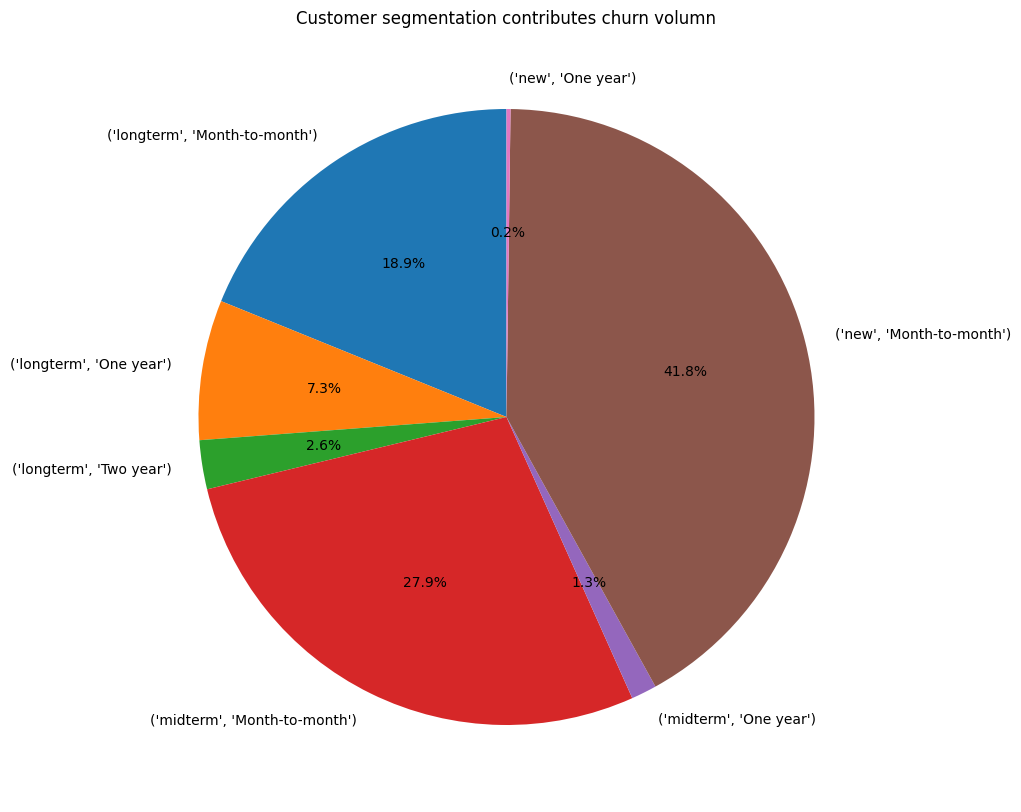

In [102]:
## Pie Chart
plt.figure(figsize=(10,10))
x = filtered_customer_segment_with_churn_pct.values
label = filtered_customer_segment_with_churn_pct.index

plt.pie(x=x, labels=label, autopct='%1.1f%%', startangle=90)
plt.title('Customer segmentation contributes churn volumn');

## Demographic & Customer Profile Analysis

### 1. Does churn vary by gender?

In [104]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,new,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,longterm,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [109]:
## Churn variation by gender
churn_variation_by_gender = df.groupby(['gender'])['Churn'].value_counts(normalize=True).round(2).to_frame()

churn_variation_by_gender

proportion
gender Churn            
Female No           0.73
       Yes          0.27
Male   No           0.74
       Yes          0.26

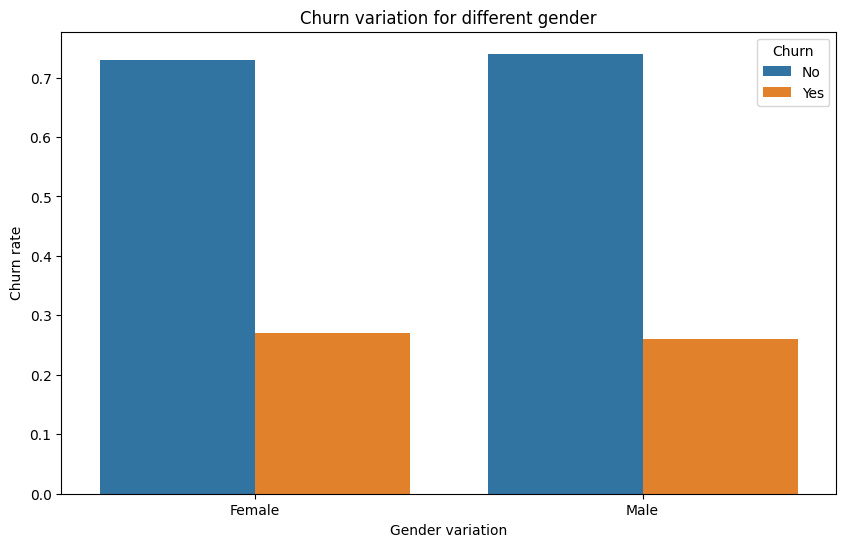

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=churn_variation_by_gender, x='gender', y='proportion', hue='Churn')
plt.xlabel("Gender variation")
plt.ylabel("Churn rate")
plt.title("Churn variation for different gender");

#### Comments:
The above analysis indicates that:
* Churn rate is higher for female customers (approximately 27%) compared to male customers (around 26%).

### 2. Are senior citizens more likely to churn?

In [115]:
## Churn rate of senior citizen
churn_rate_of_senior_citizen = df.groupby(['SeniorCitizen'])['Churn'].value_counts(normalize=True).to_frame()

churn_rate_of_senior_citizen

proportion
SeniorCitizen Churn            
0             No       0.763476
              Yes      0.236524
1             No       0.583333
              Yes      0.416667

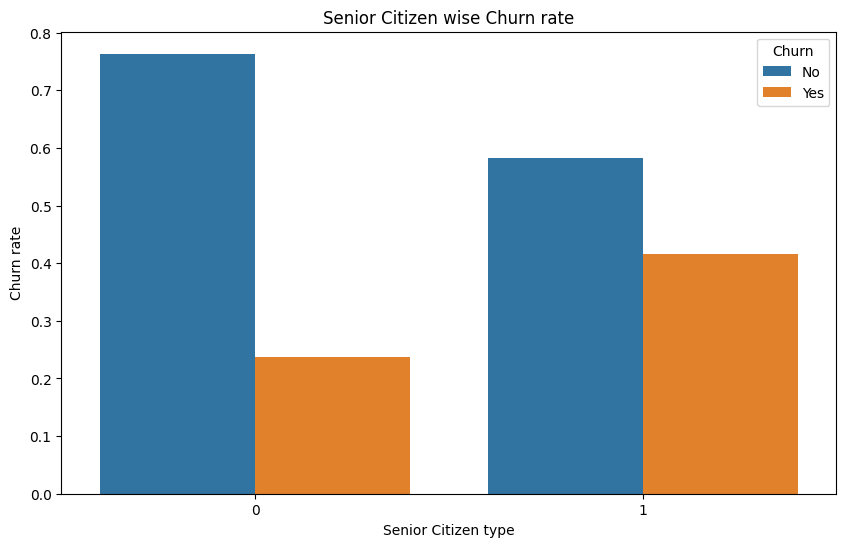

In [116]:
plt.figure(figsize=(10,6))
sns.barplot(data=churn_rate_of_senior_citizen, x='SeniorCitizen', y='proportion', hue='Churn')
plt.xlabel("Senior Citizen type")
plt.ylabel("Churn rate")
plt.title("Senior Citizen wise Churn rate");

#### Comments:
From the above analysis we can clearly see that:
* Senior citizens have a higher churn rate (approximately 41%) compared to non-senior citizens (around 23%). 

This suggests that age may be a factor influencing customer retention, with older customers being more prone to discontinuing the service.

### 3. How does churn differ for customers with partners or dependents?

In [117]:
## How churn vary by customer partner wise
partner_wise_churn_rate = df.groupby(['Partner'])['Churn'].value_counts(normalize=True).round(2).to_frame()

partner_wise_churn_rate

proportion
Partner Churn            
No      No           0.67
        Yes          0.33
Yes     No           0.80
        Yes          0.20

In [118]:
## How churn vary by customer dependents wise
dependents_wise_churn_rate = df.groupby(['Dependents'])['Churn'].value_counts(normalize=True).round(2).to_frame()

dependents_wise_churn_rate

proportion
Dependents Churn            
No         No           0.69
           Yes          0.31
Yes        No           0.84
           Yes          0.16

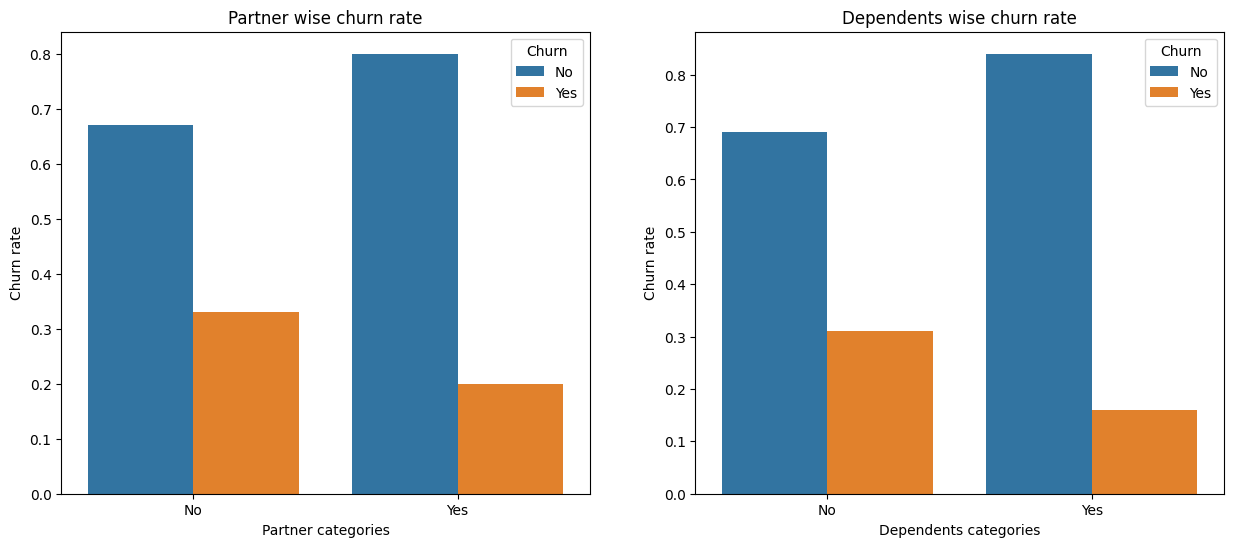

In [119]:
plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
sns.barplot(data=partner_wise_churn_rate, x='Partner', y='proportion', hue='Churn')
plt.title("Partner wise churn rate")
plt.xlabel("Partner categories")
plt.ylabel("Churn rate");

plt.subplot(1, 2, 2)
sns.barplot(data=dependents_wise_churn_rate, x='Dependents', y='proportion', hue='Churn')
plt.title("Dependents wise churn rate")
plt.xlabel("Dependents categories")
plt.ylabel("Churn rate");

#### Comments:
The above analysis shows that:
* Customers without partners have a higher churn rate (approximately 33%) compared to those with partners (around 20%).
* Similarly, customers without dependents exhibit a higher churn rate (about 31%) than those with dependents (approximately 16%).

### 4. Which demographic group has the highest churn probability?

Understanding churn rate across differnent demographic groups(gender, senior citizen, and contract type) can help in identifying vulnerable segments and tailoring retention strategies accordingly.

In [48]:
pd.pivot_table(data=df, index=['Churn', 'Partner', 'Dependents'], columns=['gender', 'SeniorCitizen'], aggfunc='size')

gender                   Female      Male     
SeniorCitizen                 0    1    0    1
Churn Partner Dependents                      
No    No      No            909  159  962  126
              Yes           110    2  166    4
      Yes     No            482  136  438  176
              Yes           710   31  713   31
Yes   No      No            428  158  418  117
              Yes            32    1   43    1
      Yes     No            113   73  128  105
              Yes           124    8  105   12

#### Comments:
* The analysis shows that there are 32 possible demographic groups based on the combinations.
* Among all possible demographic groups the one with the highest churn number is (Gender: Female, Senior Citizen: No, Partner: No, Dependents: No) with a churn count of 428.
* So this demographic group has the highest churn probability and should be targeted for retention efforts.

### 5. Is there a demographic segment that is low churn but high revenue?

In [133]:
demographic_segment_with_revenue = df.groupby(['Churn', 'gender' ,'Partner', 'SeniorCitizen', 'Dependents']).agg({'Churn' : 'size', 'TotalCharges' : 'sum'}).loc['Yes', :].sort_values(by=['TotalCharges'], ascending=False)

demographic_segment_with_revenue

Churn  TotalCharges
gender Partner SeniorCitizen Dependents                     
Male   No      0             No            418     446439.30
Female No      0             No            428     420269.30
Male   Yes     0             No            128     330260.90
               1             No            105     263073.95
Female Yes     0             No            113     245110.85
                             Yes           124     236720.05
Male   Yes     0             Yes           105     226882.90
Female No      1             No            158     211737.40
       Yes     1             No             73     184059.00
Male   No      1             No            117     156377.15
       Yes     1             Yes            12      47452.70
       No      0             Yes            43      39270.45
Female No      0             Yes            32      31095.55
       Yes     1             Yes             8      19544.15
       No      1             Yes             1         71.00
Male   No      1             Yes             1         50.15

In [136]:
demographic_segment_with_revenue['Per_churn_revenue'] = (demographic_segment_with_revenue['TotalCharges']/demographic_segment_with_revenue['Churn'])

demographic_segment_with_revenue.sort_values(by=['Per_churn_revenue'], ascending=False)

Churn  TotalCharges  \
gender Partner SeniorCitizen Dependents                        
Male   Yes     1             Yes            12      47452.70   
               0             No            128     330260.90   
Female Yes     1             No             73     184059.00   
Male   Yes     1             No            105     263073.95   
Female Yes     1             Yes             8      19544.15   
               0             No            113     245110.85   
Male   Yes     0             Yes           105     226882.90   
Female Yes     0             Yes           124     236720.05   
       No      1             No            158     211737.40   
Male   No      1             No            117     156377.15   
               0             No            418     446439.30   
Female No      0             No            428     420269.30   
                             Yes            32      31095.55   
Male   No      0             Yes            43      39270.45   
Female No      1             Yes             1         71.00   
Male   No      1             Yes             1         50.15   

                                         Per_churn_revenue  
gender Partner SeniorCitizen Dependents                     
Male   Yes     1             Yes               3954.391667  
               0             No                2580.163281  
Female Yes     1             No                2521.356164  
Male   Yes     1             No                2505.466190  
Female Yes     1             Yes               2443.018750  
               0             No                2169.122566  
Male   Yes     0             Yes               2160.789524  
Female Yes     0             Yes               1909.032661  
       No      1             No                1340.110127  
Male   No      1             No                1336.556838  
               0             No                1068.036603  
Female No      0             No                 981.937617  
                             Yes                971.735937  
Male   No      0             Yes                913.266279  
Female No      1             Yes                 71.000000  
Male   No      1             Yes                 50.150000

#### Comments:
The analysis indicates that there is a demographic group (Gender: Male, Partner: Yes, Senior Citizen: Yes, Dependents: Yes) that exhibits a low churn count but highest revenue (approximately 3954.39) per churned customer. This suggests that this segment is valuable to the company, and efforts should be made to retain these customers.